In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

In [ ]:
dataset_path = '/content/drive/MyDrive/Classroom/data'

In [ ]:
image_extensions = ('.jpg', '.jpeg', '.png','.webp')

image_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("Total Images:", len(image_files))

Total Images: 129


# Count Number of files

In [ ]:
print(image_files)

['/content/drive/MyDrive/Classroom/data/1.jpg', '/content/drive/MyDrive/Classroom/data/3.jpg', '/content/drive/MyDrive/Classroom/data/2.jpg', '/content/drive/MyDrive/Classroom/data/5.jpg', '/content/drive/MyDrive/Classroom/data/6.jpg', '/content/drive/MyDrive/Classroom/data/7.jpg', '/content/drive/MyDrive/Classroom/data/9.jpg', '/content/drive/MyDrive/Classroom/data/10.jpg', '/content/drive/MyDrive/Classroom/data/12.jpg', '/content/drive/MyDrive/Classroom/data/4.jpg', '/content/drive/MyDrive/Classroom/data/13.jpg', '/content/drive/MyDrive/Classroom/data/11.jpg', '/content/drive/MyDrive/Classroom/data/14.jpg', '/content/drive/MyDrive/Classroom/data/15.jpg', '/content/drive/MyDrive/Classroom/data/16.jpg', '/content/drive/MyDrive/Classroom/data/8.jpg', '/content/drive/MyDrive/Classroom/data/18.jpg', '/content/drive/MyDrive/Classroom/data/17.jpg', '/content/drive/MyDrive/Classroom/data/19.jpg', '/content/drive/MyDrive/Classroom/data/20.jpg', '/content/drive/MyDrive/Classroom/data/21.jpg', 

In [ ]:
formats = {}

for img_path in image_files:
    img = Image.open(img_path)
    fmt = img.format

    if fmt in formats:
        formats[fmt] += 1
    else:
        formats[fmt] = 1

print(formats)

{'GIF': 7, 'JPEG': 84, 'WEBP': 21, 'PNG': 15, 'BMP': 2}


In [ ]:
sizes = []

for img_path in image_files:
    img = Image.open(img_path)
    sizes.append(img.size)

sizes[:10]

'''
First value → Width
Second value → Height
'''

[(304, 351),
 (400, 261),
 (720, 1280),
 (1024, 1024),
 (675, 1200),
 (1024, 1024),
 (624, 498),
 (960, 1280),
 (1110, 344),
 (2400, 3600)]

In [ ]:
width =[i[0] for i in sizes]  # List Comprehension
height = [i[1] for i in sizes]
print(max(width))
print(min(width))
print(max(height))
print(min(height))

3120
191
4160
139


# Average image size

In [ ]:
print("Average Width :", np.mean(width))
print("Average Height :", np.mean(height))

Average Width : 833.6201550387597
Average Height : 934.6821705426356


#Detect corrupted images

In [ ]:
corrupted = []

for img_path in image_files:
    try:
        img = Image.open(img_path)
        img.verify()
    except:
        corrupted.append(img_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


#Display sample images

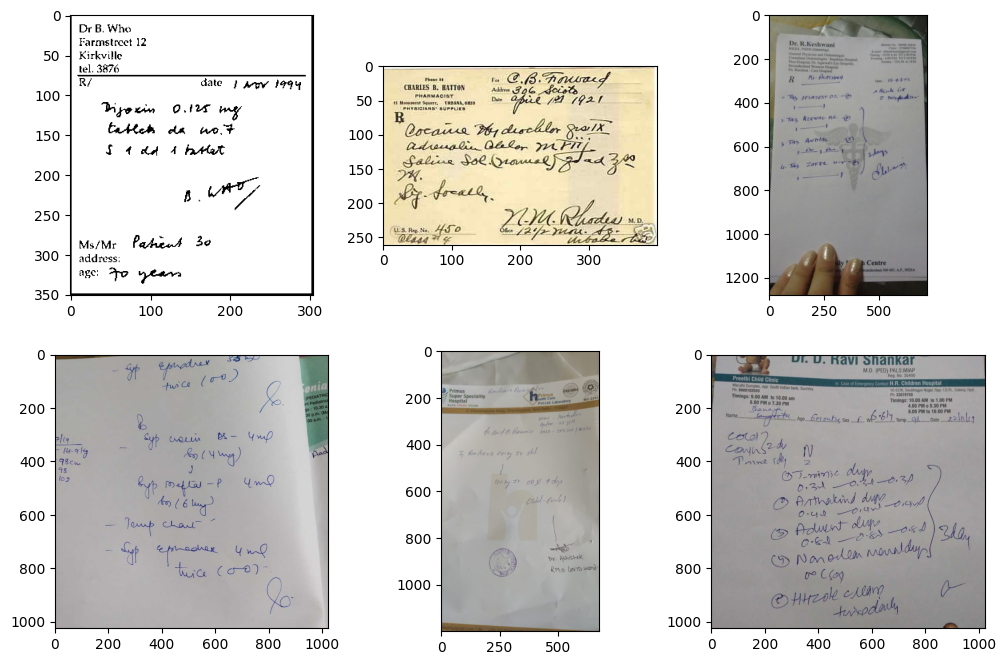

In [ ]:
plt.figure(figsize=(12,8))

for i in range(6):
    img = Image.open(image_files[i])

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("on")

plt.show()

#Check RGB or grayscale

In [ ]:
modes = {}

for img_path in image_files:
    img = Image.open(img_path)

    if img.mode in modes:
        modes[img.mode]+=1
    else:
        modes[img.mode]=1

print(modes)

# RBG- color image
# L-Grayscale
#RGBA-color+transparency

{'P': 10, 'RGB': 108, 'L': 5, 'RGBA': 6}


# Analyze image dimension

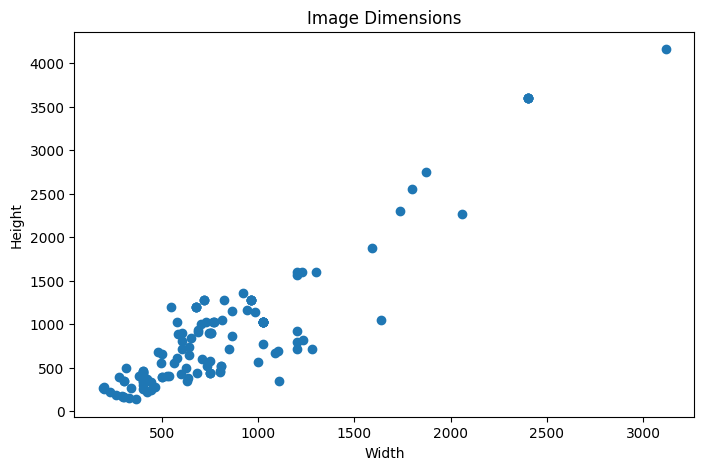

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(width, height)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Dimensions")

plt.show()

# Image size distribution

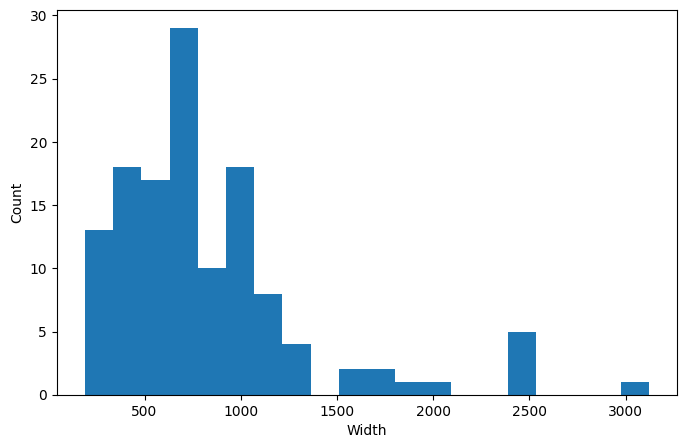

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(width, bins=20)

plt.xlabel("Width")
plt.ylabel("Count")

plt.show()

# Resize image (preprocessing)

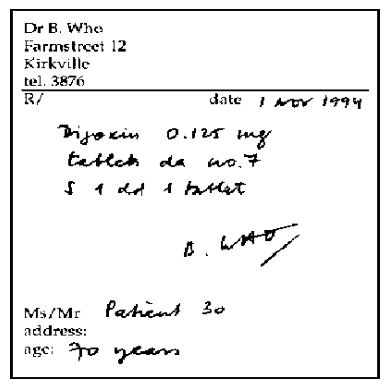

In [ ]:
img = Image.open(image_files[0])

img = img.resize((400,400))

plt.imshow(img)
plt.axis("off")
plt.show()

#Normalize Pixel Values

In [ ]:
img_array = np.array(img)

img_array = img_array / 255.0

print(img_array.min())
print(img_array.max())

0.0
0.00392156862745098


#Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

In [ ]:
print("Total Images :", len(image_files))
print("Formats :", formats)
print("Corrupted Images :", len(corrupted))
print("Average Width :", np.mean(width))
print("Average Height :", np.mean(height))

Total Images : 129
Formats : {'GIF': 7, 'JPEG': 84, 'WEBP': 21, 'PNG': 15, 'BMP': 2}
Corrupted Images : 0
Average Width : 833.6201550387597
Average Height : 934.6821705426356
